In [5]:
import pandas as pd
import scipy.stats as stats
import numpy as np

In [6]:
data = pd.read_csv("RGR2_A-7_X1-X4.csv", sep=';')

x1 = data["X1"]
x2 = data["X2"]
x3 = data["X3"]
x4 = data["X4"]
alpha = 0.05
n = len(x1)

print("--- РГР №2: Проверка статистических гипотез ---")
print(f"Вариант: А-7. Объем выборки n = {n}")


# ---------------------------------------------------------
# ПУНКТ 4.1: Cхема проверки
# ---------------------------------------------------------
print("\n" + "="*100)
print("4.1. Cхема проверки")
print(f"Уровень значимости: alpha = {alpha}")
print("Критерий принятия решения: Если t в критической области, нулевая гипотеза (H0) отвергается.")

# ---------------------------------------------------------
# ПУНКТ 4.2: Сравнение средних X1 и X2 (Параметрический)
# ---------------------------------------------------------
print("\n" + "="*100)
print("4.2. Проверка гипотезы о равенстве матожиданий двух независимых нормальных совокупностей")
print("\n1. Гипотезы:")
print("   H0: EX1 = EX2 (средние равны)")
print("   H1: EX1 ≠ EX2 (средние не равны)")


t_stat, p_value = stats.ttest_ind(x1, x2, equal_var=True)

print(f"\n2. Выбранный критерий: t-критерий Стьюдента для независимых выборок.")

print(f"\n3. Значение статистики:")

print(f"   t-набл = {t_stat:.4f}")

print(f"\n4. Критическая область:")

# 4. p-value и критическая область
alpha = 0.05  # уровень значимости
df = len(x1) + len(x2) - 2  # степени свободы (для equal_var=True)

# Критическое значение для двустороннего теста
t_crit = stats.t.ppf(1 - alpha/2, df)

print(f"   Критическая область: |t| > {t_crit:.4f}, p-value: {p_value:.9f}")


print("\n5. Вывод:")
if p_value < alpha:
    print("   H0 отвергается. Средние значения X1 и X2 имеют статистически значимые различия.")
else:
    print("   H0 не отвергается. Статистически значимых различий между X1 и X2 не обнаружено.")

# ---------------------------------------------------------
# ПУНКТ 4.3: Проверка гипотезы о параметре mu для X3
# ---------------------------------------------------------
mu0 = 86.80
print("\n" + "="*100)
print(f"4.3. Проверка гипотезы о параметре нормального распределения (X3)")
print(f"\n1. Гипотезы:")
print(f"   H0: mu = {mu0}")
print(f"   H1: mu ≠ {mu0}")

t_stat_3, p_value_3 = stats.ttest_1samp(x3, mu0)

print(f"\n2. Результаты вычислений:")
print(f"   t-набл = {t_stat_3:.4f}, Критическая область: |t| > {t_crit:.4f}, , p-value: {p_value_3:.4f}")

print("\n3. Вывод:")
if p_value_3 < alpha:
    print(f"   H0 отвергается. Среднее X3 значимо отличается от {mu0}.")
else:
    print(f"   H0 не отвергается. Среднее X3 соответствует значению {mu0}.")

# # ---------------------------------------------------------
# # ПУНКТ 4.4: Непараметрический критерий (Манна-Уитни)
# # ---------------------------------------------------------
print("\n" + "="*100)
print("4.4. Непараметрический критерий для X1 и X2")
u_stat, p_value_mw = stats.mannwhitneyu(x1, x2, alternative='two-sided')
print(f"Критерий Манна-Уитни: U = {u_stat}, p-value = {p_value_mw:.8f}")
if p_value_mw < alpha:
    print("Вывод: H0 отвергается (непараметрически). Распределения выборок сдвинуты относительно друг друга.")
else:
    print("Вывод: H0 не отвергается. Статистически значимых различий в сдвиге не обнаружено.")

# ---------------------------------------------------------
# ПУНКТ 4.5: Критерий согласия Пирсона для X4
# ---------------------------------------------------------
lambd = 0.053
print("\n" + "="*100)
print(f"4.5. Проверка гипотезы о показательном распределении X4 (lambda = {lambd})")
print("\n1. Гипотезы:")
print(f"   H0: X4 распределена по показательному закону с пар. {lambd}")
print(f"   H1: X4 не соответствует этому закону")

# Группировка данных (создание интервалов)
# Обычно берем k = 1 + 3.322 * log10(n)
k = int(1 + 3.322 * np.log10(n))
counts, bins = np.histogram(x4, bins=k)

# Теоретические вероятности для экспоненциального распределения: P = F(x_right) - F(x_left)
# F(x) = 1 - exp(-lambda * x)
cdf = lambda val: 1 - np.exp(-lambd * val)

expected_probs = []
for i in range(len(bins)-1):
    p = cdf(bins[i+1]) - cdf(bins[i])
    expected_probs.append(p)

# Корректировка последней вероятности, чтобы сумма была равна 1
expected_probs = np.array(expected_probs)
expected_probs = expected_probs / expected_probs.sum()

expected_counts = expected_probs * n

print(f"\n2. Выбранный критерий: Критерий согласия Пирсона (хи-квадрат).")
print(f"   Ошибка первого рода: Риск признать распределение не показательным, когда оно им является.")

# Вычисление статистики
chi2_stat, p_value_chi = stats.chisquare(f_obs=counts, f_exp=expected_counts)

print(f"\n4. Результаты вычислений:")
print(f"   Количество интервалов: {k}")
print(f"   khi^2-набл = {chi2_stat:.4f}, p-value = {p_value_chi:.6f}")

print("\n5. Вывод:")
if p_value_chi < alpha:
    print("   H0 отвергается. Распределение X4 не является показательным с данными параметрами.")
else:
    print("   H0 не отвергается. Данные не противоречат гипотезе о показательном распределении.")




--- РГР №2: Проверка статистических гипотез ---
Вариант: А-7. Объем выборки n = 97

4.1. Cхема проверки
Уровень значимости: alpha = 0.05
Критерий принятия решения: Если t в критической области, нулевая гипотеза (H0) отвергается.

4.2. Проверка гипотезы о равенстве матожиданий двух независимых нормальных совокупностей

1. Гипотезы:
   H0: EX1 = EX2 (средние равны)
   H1: EX1 ≠ EX2 (средние не равны)

2. Выбранный критерий: t-критерий Стьюдента для независимых выборок.

3. Значение статистики:
   t-набл = 6.3024

4. Критическая область:
   Критическая область: |t| > 1.9724, p-value: 0.000000002

5. Вывод:
   H0 отвергается. Средние значения X1 и X2 имеют статистически значимые различия.

4.3. Проверка гипотезы о параметре нормального распределения (X3)

1. Гипотезы:
   H0: mu = 86.8
   H1: mu ≠ 86.8

2. Результаты вычислений:
   t-набл = -4.0605, Критическая область: |t| > 1.9724, , p-value: 0.0001

3. Вывод:
   H0 отвергается. Среднее X3 значимо отличается от 86.8.

4.4. Непараметрическ

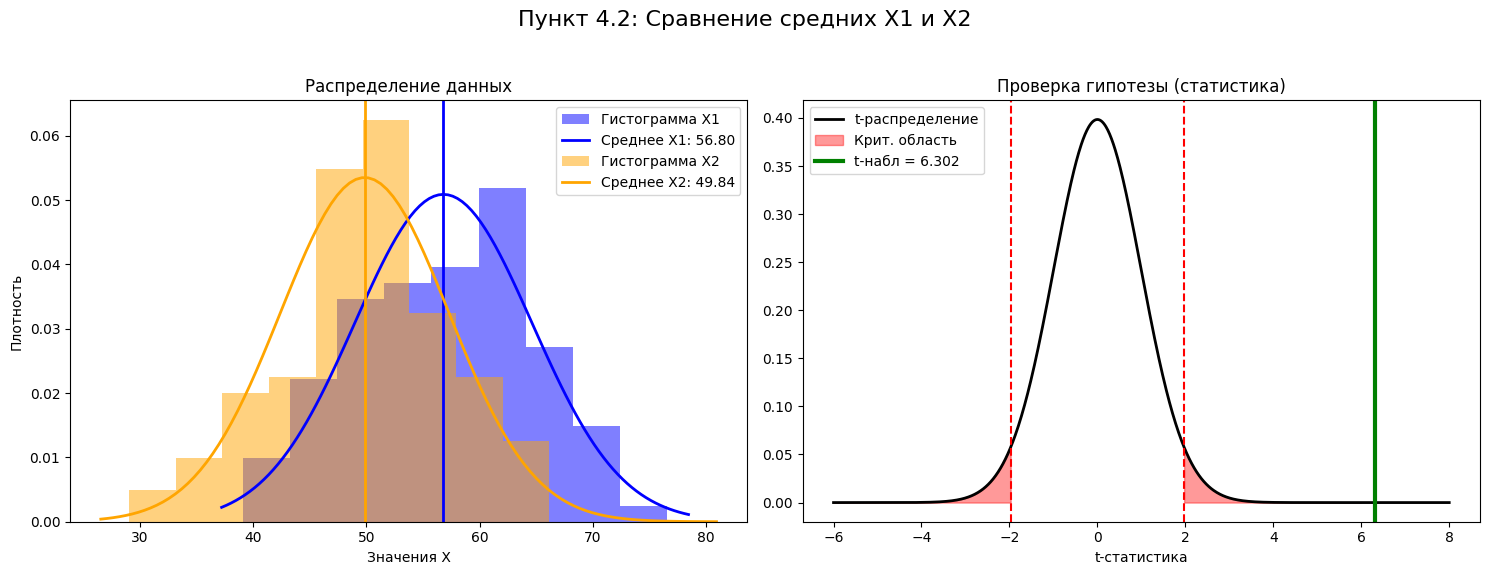

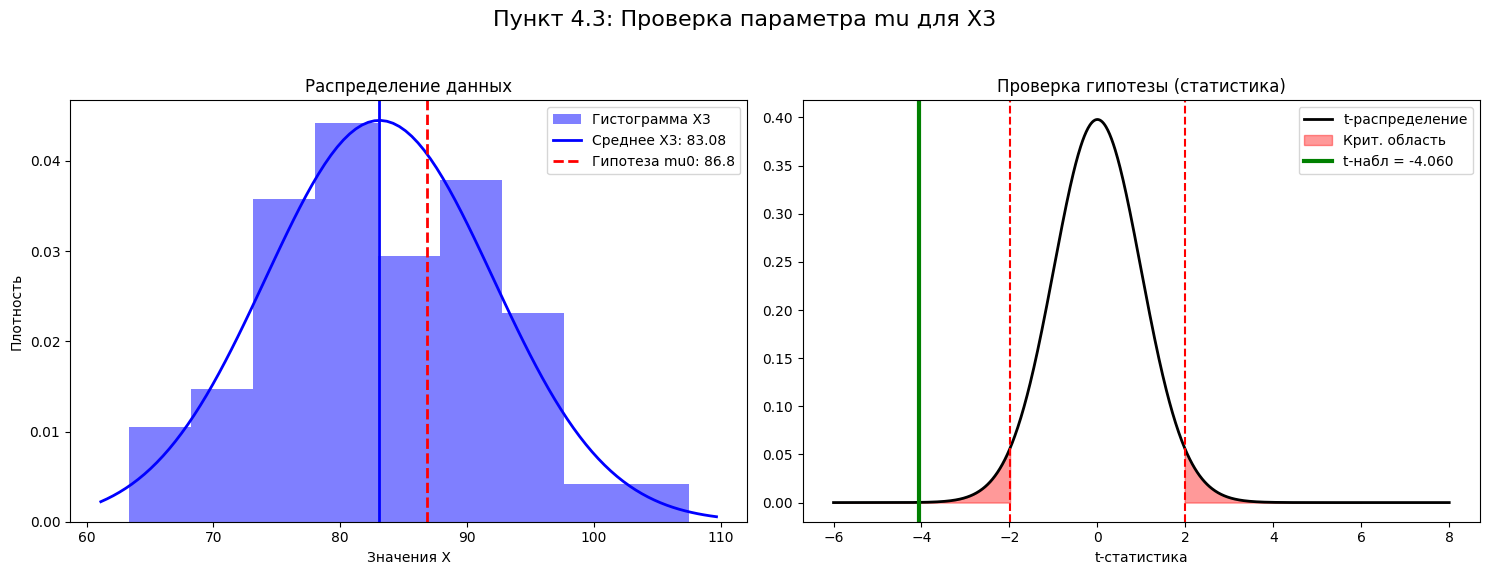

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

def plot_hypothesis_test(data_list, labels, t_obs, t_crit, df, title, mu0=None):
    """
    data_list: список массивов данных (один для 1-samp, два для 2-samp)
    labels: названия выборок
    t_obs: наблюдаемое t
    t_crit: критическое t
    df: степени свободы
    title: заголовок
    mu0: проверяемое среднее (только для 4.3)
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # --- ЛЕВЫЙ ГРАФИК: Гистограмма данных ---
    colors = ['blue', 'orange']
    for i, data in enumerate(data_list):
        ax1.hist(data, bins=9, alpha=0.5, label=f'Гистограмма {labels[i]}', color=colors[i], density=True)
        # Накладываем кривую нормального распределения для наглядности
        mu_fit, std_fit = stats.norm.fit(data)
        xmin, xmax = ax1.get_xlim()
        x_norm = np.linspace(xmin, xmax, 100)
        p_norm = stats.norm.pdf(x_norm, mu_fit, std_fit)
        ax1.plot(x_norm, p_norm, color=colors[i], lw=2)
        ax1.axvline(np.mean(data), color=colors[i], linestyle='-', lw=2, label=f'Среднее {labels[i]}: {np.mean(data):.2f}')

    if mu0 is not None:
        ax1.axvline(mu0, color='red', linestyle='--', lw=2, label=f'Гипотеза mu0: {mu0}')

    ax1.set_title("Распределение данных")
    ax1.set_xlabel("Значения X")
    ax1.set_ylabel("Плотность")
    ax1.legend()

    # --- ПРАВЫЙ ГРАФИК: t-распределение (статистика) ---
    x_t = np.linspace(-6, 8, 1000)
    y_t = stats.t.pdf(x_t, df)
    ax2.plot(x_t, y_t, color='black', lw=2, label='t-распределение')

    # Хвосты
    x_left = np.linspace(-6, -t_crit, 100)
    ax2.fill_between(x_left, stats.t.pdf(x_left, df), color='red', alpha=0.4, label='Крит. область')
    x_right = np.linspace(t_crit, 6, 100)
    ax2.fill_between(x_right, stats.t.pdf(x_right, df), color='red', alpha=0.4)

    # Наблюдаемое значение
    ax2.axvline(t_obs, color='green', lw=3, label=f't-набл = {t_obs:.3f}')
    ax2.axvline(t_crit, color='red', linestyle='--')
    ax2.axvline(-t_crit, color='red', linestyle='--')

    ax2.set_title("Проверка гипотезы (статистика)")
    ax2.set_xlabel("t-статистика")
    ax2.legend()

    plt.suptitle(title, fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# --- ВЫЗОВ ДЛЯ ПУНКТА 4.2 (X1 vs X2) ---
df_42 = len(x1) + len(x2) - 2
t_crit_42 = stats.t.ppf(1 - alpha/2, df_42)
plot_hypothesis_test([x1, x2], ["X1", "X2"], t_stat, t_crit_42, df_42, "Пункт 4.2: Сравнение средних X1 и X2")

# --- ВЫЗОВ ДЛЯ ПУНКТА 4.3 (X3 vs mu0) ---
df_43 = len(x3) - 1
t_crit_43 = stats.t.ppf(1 - alpha/2, df_43)
plot_hypothesis_test([x3], ["X3"], t_stat_3, t_crit_43, df_43, "Пункт 4.3: Проверка параметра mu для X3", mu0=mu0)

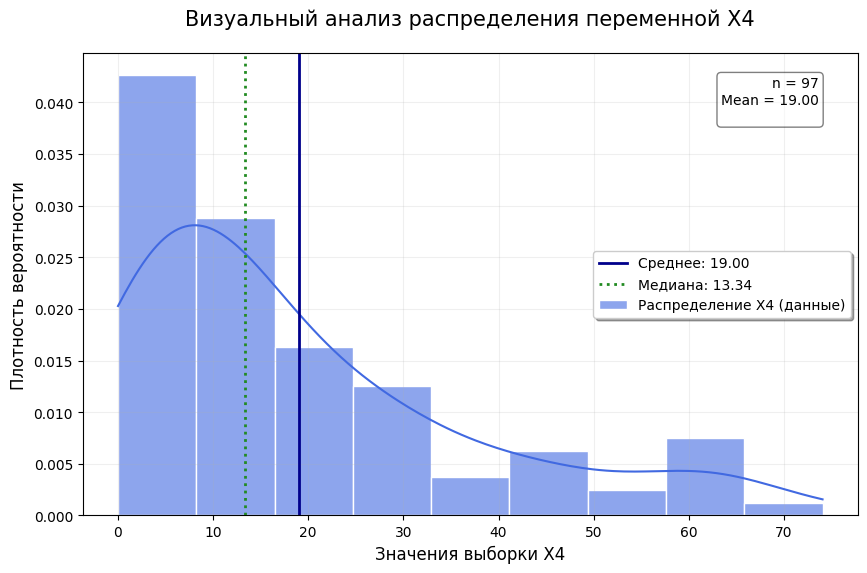

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

# Настройка стиля
plt.style.use('seaborn-v0_8-muted') # Мягкий вайбовый стиль
fig, ax = plt.subplots(figsize=(10, 6))

# Данные для анализа
data_x4 = x4.dropna() # На всякий случай убираем пустые значения

# 1. Строим гистограмму
sns.histplot(data_x4, bins=9, kde=True, stat="density", color='royalblue',
             label='Распределение X4 (данные)', edgecolor='white', alpha=0.6)

# 2. Накладываем теоретическую кривую нормального распределения (Bell Curve)
mu, std = stats.norm.fit(data_x4)
x_axis = np.linspace(data_x4.min() - 5, data_x4.max() + 5, 100)

# 3. Добавляем индикаторы среднего и медианы
plt.axvline(mu, color='darkblue', linestyle='-', lw=2, label=f'Среднее: {mu:.2f}')
plt.axvline(data_x4.median(), color='forestgreen', linestyle=':', lw=2, label=f'Медиана: {data_x4.median():.2f}')

# Фишки для "вайба" и красоты
plt.title('Визуальный анализ распределения переменной X4', fontsize=15, pad=20)
plt.xlabel('Значения выборки X4', fontsize=12)
plt.ylabel('Плотность вероятности', fontsize=12)

# Добавляем текстовое окошко со статистикой прямо на график
stats_text = (f'n = {len(data_x4)}\n'
              f'Mean = {mu:.2f}\n') # Коэффициент асимметрии
plt.text(0.95, 0.95, stats_text, transform=ax.transAxes, fontsize=10,
         verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

plt.legend(frameon=True, shadow=True)
plt.grid(alpha=0.2)

plt.show()